# Tutorial 2: Surface Codes and Lattice Surgery
This notebook accompanies **Tutorial 03: Rotated Surface Codes**. Read it after [the Shor notebook](shor_tutorial.ipynb). Familiarity with Pauli operators, stabilizers, and CNOT is assumed.

We first build a rotated surface-code patch and test its memory in ideal and noisy simulations. We then use lattice surgery to prepare a logical GHZ state across three patches. Loom defines and interprets the experiments, Stim samples their circuits, and Matplotlib plots the memory results. We inspect detector events and raw logical readouts, without applying a decoder.


## 1. The surface-code memory experiment

A **memory experiment** asks whether an encoded qubit retains its information over time. We initialize the data qubits, measure the surface-code checks over one or more rounds, and finally measure a logical operator to see whether the stored value survived.

We first define a square **lattice**. Each qubit has coordinates `(x, y, b)`, where `b=0` denotes data and `b=1` denotes an ancilla. In our figures, $x$ increases to the right and $y$ increases upward, so $y=0$ is drawn at the bottom.

We use Loom’s `RotatedSurfaceCode.create` to define a rotated surface-code patch: its data qubits, $X$ and $Z$ stabilizers, logical operators, and check-measurement circuits. In our figures, we label data qubit `(x,y,0)` as $q=x+dy$. Orange faces represent $X$ checks; teal faces represent $Z$ checks.

By default, `x_boundary="horizontal"`, giving a horizontal logical $X$ and vertical logical $Z$. `weight_2_stab_is_first_row` chooses whether the first two-qubit boundary check starts at row $y=0$. This also sets the checkerboard pattern: with the default horizontal boundary, the four-qubit face at $(0,0)$ is a $Z$ check when the setting is `True`, and an $X$ check when it is `False`.

The distance-three diagram below illustrates the boundary choice. The code cell that follows uses distance four.

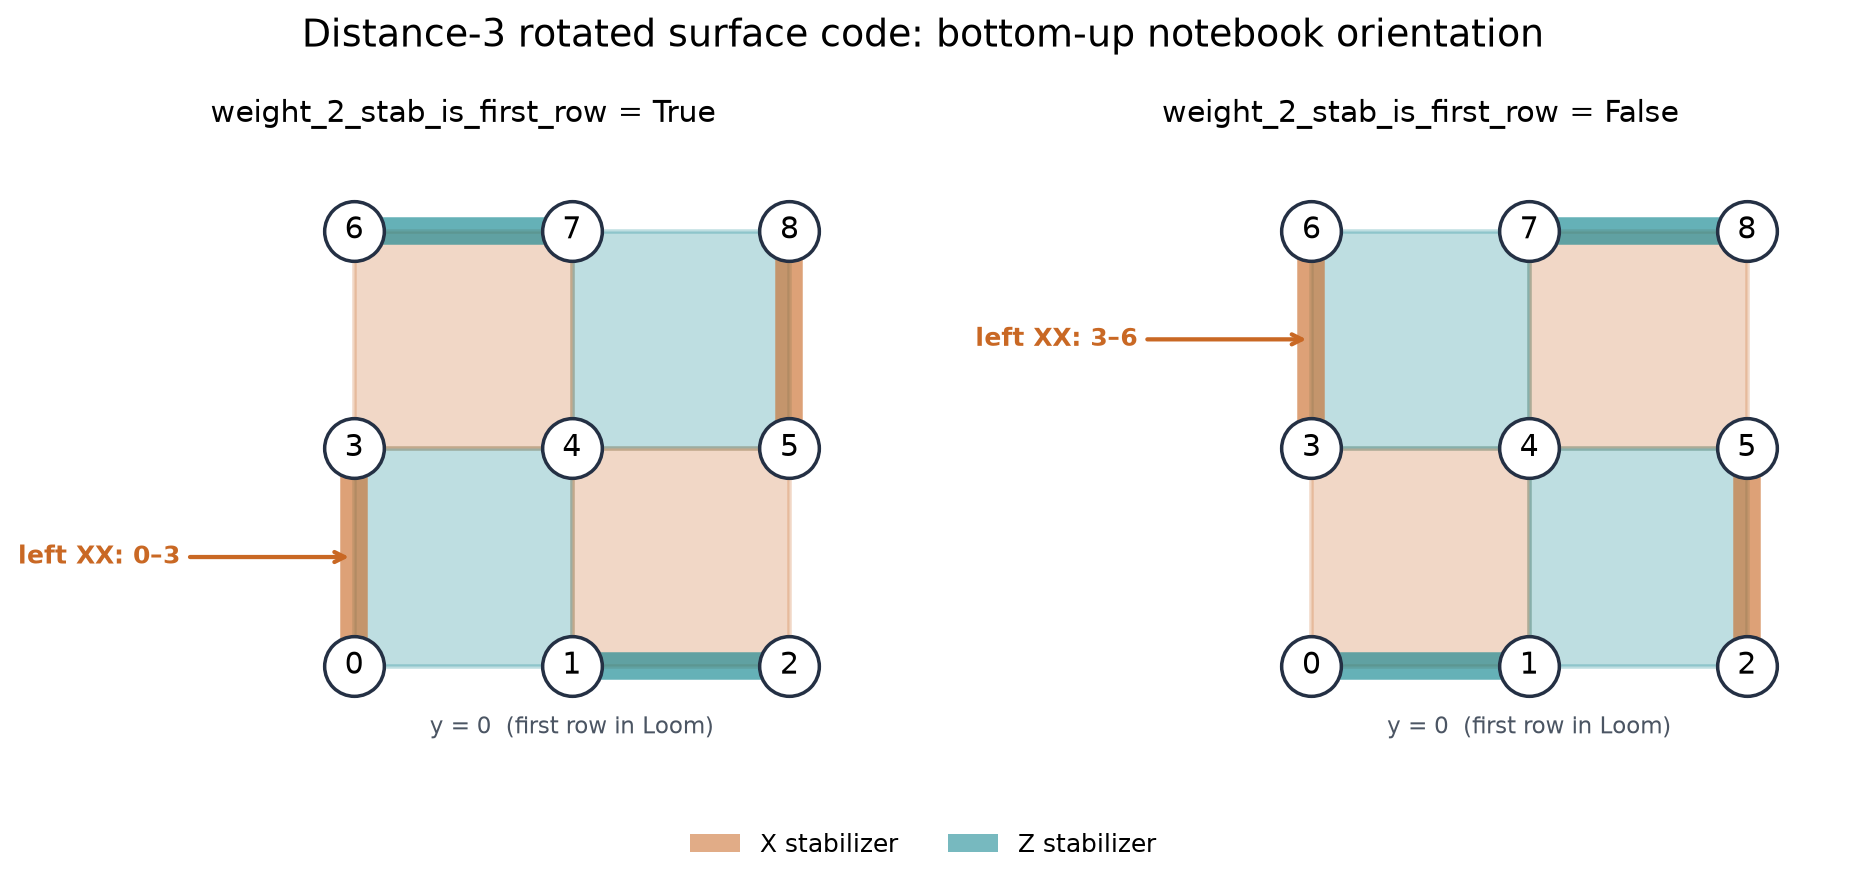

In [1]:
from loom.eka import Lattice
from loom_rotated_surface_code.code_factory import RotatedSurfaceCode
import loom.visualizer as vis

d = 4
lattice = Lattice.square_2d((d + 1, d + 1))
patch = RotatedSurfaceCode.create(
    d, d,
    lattice,
    unique_label="patch3",
    weight_2_stab_is_first_row=False, 
    # weight_4_x_schedule=FourBodySchedule.N,

)

print(f'Number of data qubits d^2: {len(patch.data_qubits)}')
print(f'Number of stabilizers d^2-1: {len(patch.stabilizers)}')

plot = vis.StabilizerPlot(
    lattice,
    title=f"Distance-{d} rotated surface code",
)
plot.add_dqubit_traces(
    [q in patch.data_qubits for q in lattice.all_qubits()]
)
plot.plot_blocks([patch], plot_logical_operators=True)
plot.show()

Number of data qubits d^2: 16
Number of stabilizers d^2-1: 15


### Noiseless simulation
The patch defines **what the code is**: its data qubits, stabilizers, logical operators, and measurement circuits. We now need to say **what happens over time**. Loom’s `Eka` object holds the lattice, the patch, and an ordered list of operations: reset the data qubits, measure the checks for several rounds, then read logical $Z$.

`interpret_eka()` turns those high-level operations into a circuit of physical gates and measurements. It also identifies the **syndromes** (check results), **detectors** (comparisons that reveal changes between results), and the final **logical observable**. Interpretation constructs the circuit; it does not produce measurement outcomes.

We then convert that circuit to Stim and sample it. Stim efficiently simulates the Clifford gates and measurements used here, allowing us to run many shots and later add noise. Loom supplies the surface-code structure and experiment sequence; Stim supplies the simulated outcomes.

**Workflow:** `patch → Eka experiment → interpreted circuit → Stim circuit → sampled results`

In [2]:
from loom.eka import Eka
from loom.eka.operations import (
    ResetAllDataQubits,
    MeasureBlockSyndromes,
    MeasureLogicalZ,
)
from loom.interpreter import interpret_eka
from loom.executor import EkaToStimConverter

memory = Eka(
    lattice=lattice,
    blocks=[patch],
    operations=[
        [ResetAllDataQubits(patch.unique_label, state="0")],
        [MeasureBlockSyndromes(patch.unique_label, n_cycles=3)],
        [MeasureLogicalZ(patch.unique_label)],
    ],
)

interpreted = interpret_eka(memory, debug_mode=False)
stim_circuit, _, _ = EkaToStimConverter().convert(interpreted)

detectors, logical_z = (
    stim_circuit.compile_detector_sampler(seed=123)
    .sample(shots=100, separate_observables=True)
)

print("Detector clicks:", detectors.sum())
print("Logical Z = 1 outcomes:", logical_z[:, 0].sum(), "out of 100")

Detector clicks: 0
Logical Z = 1 outcomes: 0 out of 100


### Adding noise

The ideal run checks that the circuit works. To see error detection in action, we now add noise and run 1,000 independent shots.

`CircuitErrorModel` attaches a noise rule to Loom’s interpreted circuit. Here, after each ancilla–data `cx` or `cz` gate used to measure a check, `DEPOLARIZING1` independently applies an $X$, $Y$, or $Z$ fault to each participating qubit with probability $p/3$ each. Resets, readout, and idle time remain ideal. We count detector events and uncorrected logical failures.

`EkaToStimConverter` then includes those noise instructions in the Stim circuit.
Stim’s detector sampler returns two arrays: 
1. `detectors` records which error-detection events occurred in each shot. `detectors.any(axis=1).sum()` counts **shots with at least one detector click**
2. `logical_z` records the final logical measurement. `logical_z[:, 0].sum()` counts shots whose final logical $Z$ result is $1$ instead of the intended $0$.

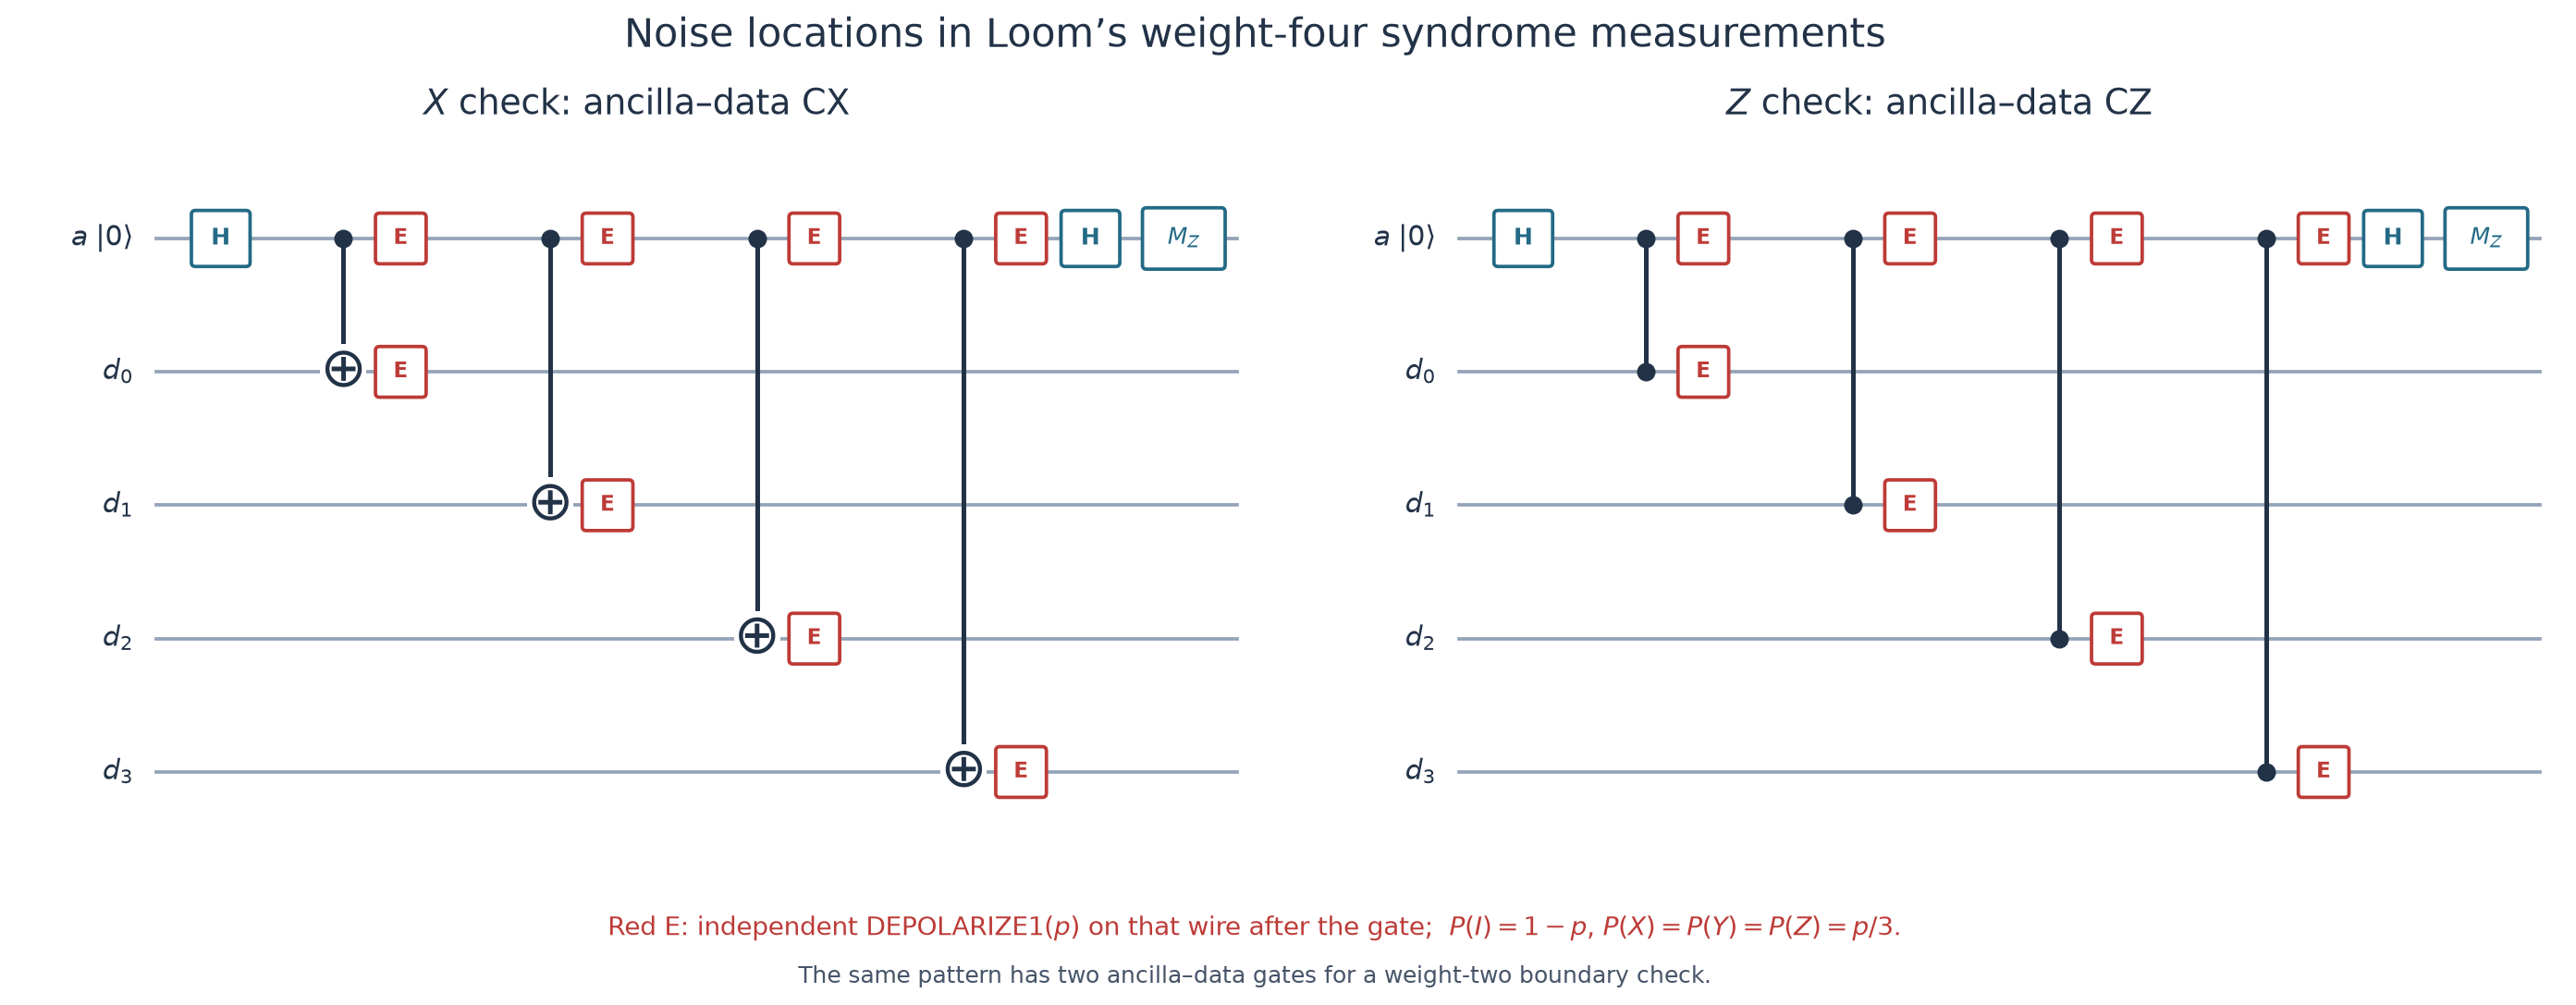

In [3]:
from loom.executor import CircuitErrorModel, ErrorType, EkaToStimConverter
from loom.executor.circuit_error_model import ApplicationMode

p = 0.005
shots = 1000

gate_noise = CircuitErrorModel(
    circuit=interpreted.final_circuit,
    error_type=ErrorType.DEPOLARIZING1,
    is_time_dependent=False,
    application_mode=ApplicationMode.AFTER_GATE,
    gate_error_probabilities={
        "cx": lambda _: [p],
        "cz": lambda _: [p],
    },
)

noisy_circuit, _, _ = EkaToStimConverter().convert(
    interpreted, error_models=[gate_noise]
)
detectors, logical_z = (
    noisy_circuit.compile_detector_sampler(seed=123)
    .sample(shots=shots, separate_observables=True)
)

print("Shots with at least one detector click:", detectors.any(axis=1).sum())
print("Shots with logical Z outcome 1:", logical_z[:, 0].sum(), "out of 1000")

Shots with at least one detector click: 732
Shots with logical Z outcome 1: 111 out of 1000


$$
P_{\mathrm{raw}}(p)
=\Pr(\text{final logical-$Z$ bit is }1
\mid \text{initial logical-$Z$ bit is }0).
$$
“Raw” means that we **do not decode** the detector outcomes or correct the final readout. This is a $Z$-basis memory test. A logical $X$ error anticommutes with logical $Z$ and flips its result; a logical $Z$ error commutes with it and is invisible to this test. To probe logical $Z$-type errors, we would instead prepare $|+_L\rangle$ and measure logical $X$.

After each selected ancilla–data gate, `DEPOLARIZING1` acts independently on both participating qubits:

$$
P(I)=1-p,\qquad P(X)=P(Y)=P(Z)=\frac{p}{3}.
$$

At small $p$, single-fault events dominate:

$$
P_{\mathrm{raw}}(p)=c_1p+c_2p^2+\cdots\approx c_1p.
$$

The coefficients $c_1,c_2,\ldots$ depend on this circuit, its number of rounds, where noise is inserted, and which observable we measure. 
Consequently,

$$
\log P_{\mathrm{raw}}\approx\log c_1+\log p,
$$

giving a log–log slope near **1**. At larger $p$, multiple faults can combine or cancel, so the straight-line approximation breaks down; the binary readout typically trends toward 50% wrong and the curve flattens.

A decoder that successfully handles every single fault would remove the linear term. For an ideal distance-four code that corrects one error, the leading failure probability could then scale as $p^2$. Whether our **circuit-level** experiment achieves that scaling depends on its fault propagation and decoder.

p = 0.00010: 66/20000 logical failures
p = 0.00026: 113/20000 logical failures
p = 0.00067: 313/20000 logical failures
p = 0.00173: 843/20000 logical failures
p = 0.00447: 2102/20000 logical failures
p = 0.01156: 4541/20000 logical failures
p = 0.02991: 7929/20000 logical failures
p = 0.07734: 9885/20000 logical failures
p = 0.20000: 10021/20000 logical failures


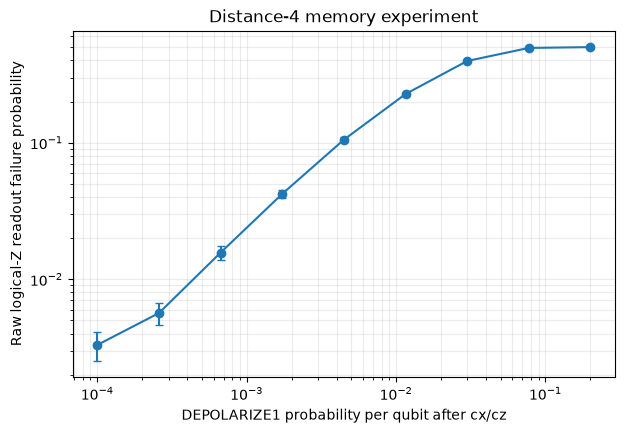

In [4]:
import numpy as np
import matplotlib.pyplot as plt

physical_rates = np.geomspace(1e-4, 2e-1, 9)
shots = 20_000
failure_counts = []

for i, p_gate in enumerate(physical_rates):
    noise = CircuitErrorModel(
        circuit=interpreted.final_circuit,
        error_type=ErrorType.DEPOLARIZING1,
        is_time_dependent=False,
        application_mode=ApplicationMode.AFTER_GATE,
        gate_error_probabilities={
            "cx": lambda _, p=p_gate: [p],
            "cz": lambda _, p=p_gate: [p],
        },
    )

    circuit, _, _ = EkaToStimConverter().convert(
        interpreted, error_models=[noise]
    )
    _, logical_z = (
        circuit.compile_detector_sampler(seed=123 + i)
        .sample(shots=shots, separate_observables=True)
    )
    failure_counts.append(int(logical_z[:, 0].sum()))

logical_rates = np.array(failure_counts) / shots
# 95% confidence interval for a binomial proportion
error_95 = 1.96 * np.sqrt(logical_rates * (1 - logical_rates) / shots)

for p_gate, failures in zip(physical_rates, failure_counts):
    print(f"p = {p_gate:.5f}: {failures}/{shots} logical failures")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    physical_rates, logical_rates, yerr=error_95,
    fmt="o-", capsize=3,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("DEPOLARIZE1 probability per qubit after cx/cz")
ax.set_ylabel("Raw logical-Z readout failure probability")
ax.set_title(f"Distance-{d} memory experiment")
ax.grid(True, which="both", alpha=0.25)
plt.show()

## 2. Logical GHZ experiment

This experiment entangles **three logical qubits**, each stored in a separate rotated surface-code patch. We prepare the patches in $|+_L\rangle|0_L\rangle|0_L\rangle$, then apply two logical CNOTs: first from patch `q1` to `q2`, then from `q1` to `q3`. Ideally, this produces

$$
|\mathrm{GHZ}_L\rangle
=\frac{|000\rangle_L+|111\rangle_L}{\sqrt{2}}.
$$

As we have seen, logical CNOTs are implemented through **lattice surgery**: the control patch grows and splits to create an auxiliary patch, that patch merges with the target, measurement-dependent corrections are tracked and the target shrinks back.
Syndrome-measurement rounds monitor the patches between these steps. The `cx` and `cz` gates used within a syndrome round are **ancilla–data gates for measuring checks**, rather than the logical CNOT between patches.

Finally, we measure all three logical qubits in the $Z$ basis. In an ideal run, the outcomes are `000` or `111`, so the $Z_1Z_2$ and $Z_2Z_3$ parities are both $+1$.

This example follows [Loom’s GHZ tutorial](https://loom-docs.entropicalabs.com/loom/tutorials/logical_ghz/). Its converter and noise examples use an older API, so the cells below use the installed Loom API.


The three distance-three patches share a $10\times12$ lattice. `q1` is the control for both logical CNOTs. The targets sit four lattice positions to its right and four positions above or below it. The space between them lets `AuxCNOT` grow `q1`, split off a temporary auxiliary patch, and merge that patch with each target in turn. The diamond marks a check ancilla at $(7,11)$.

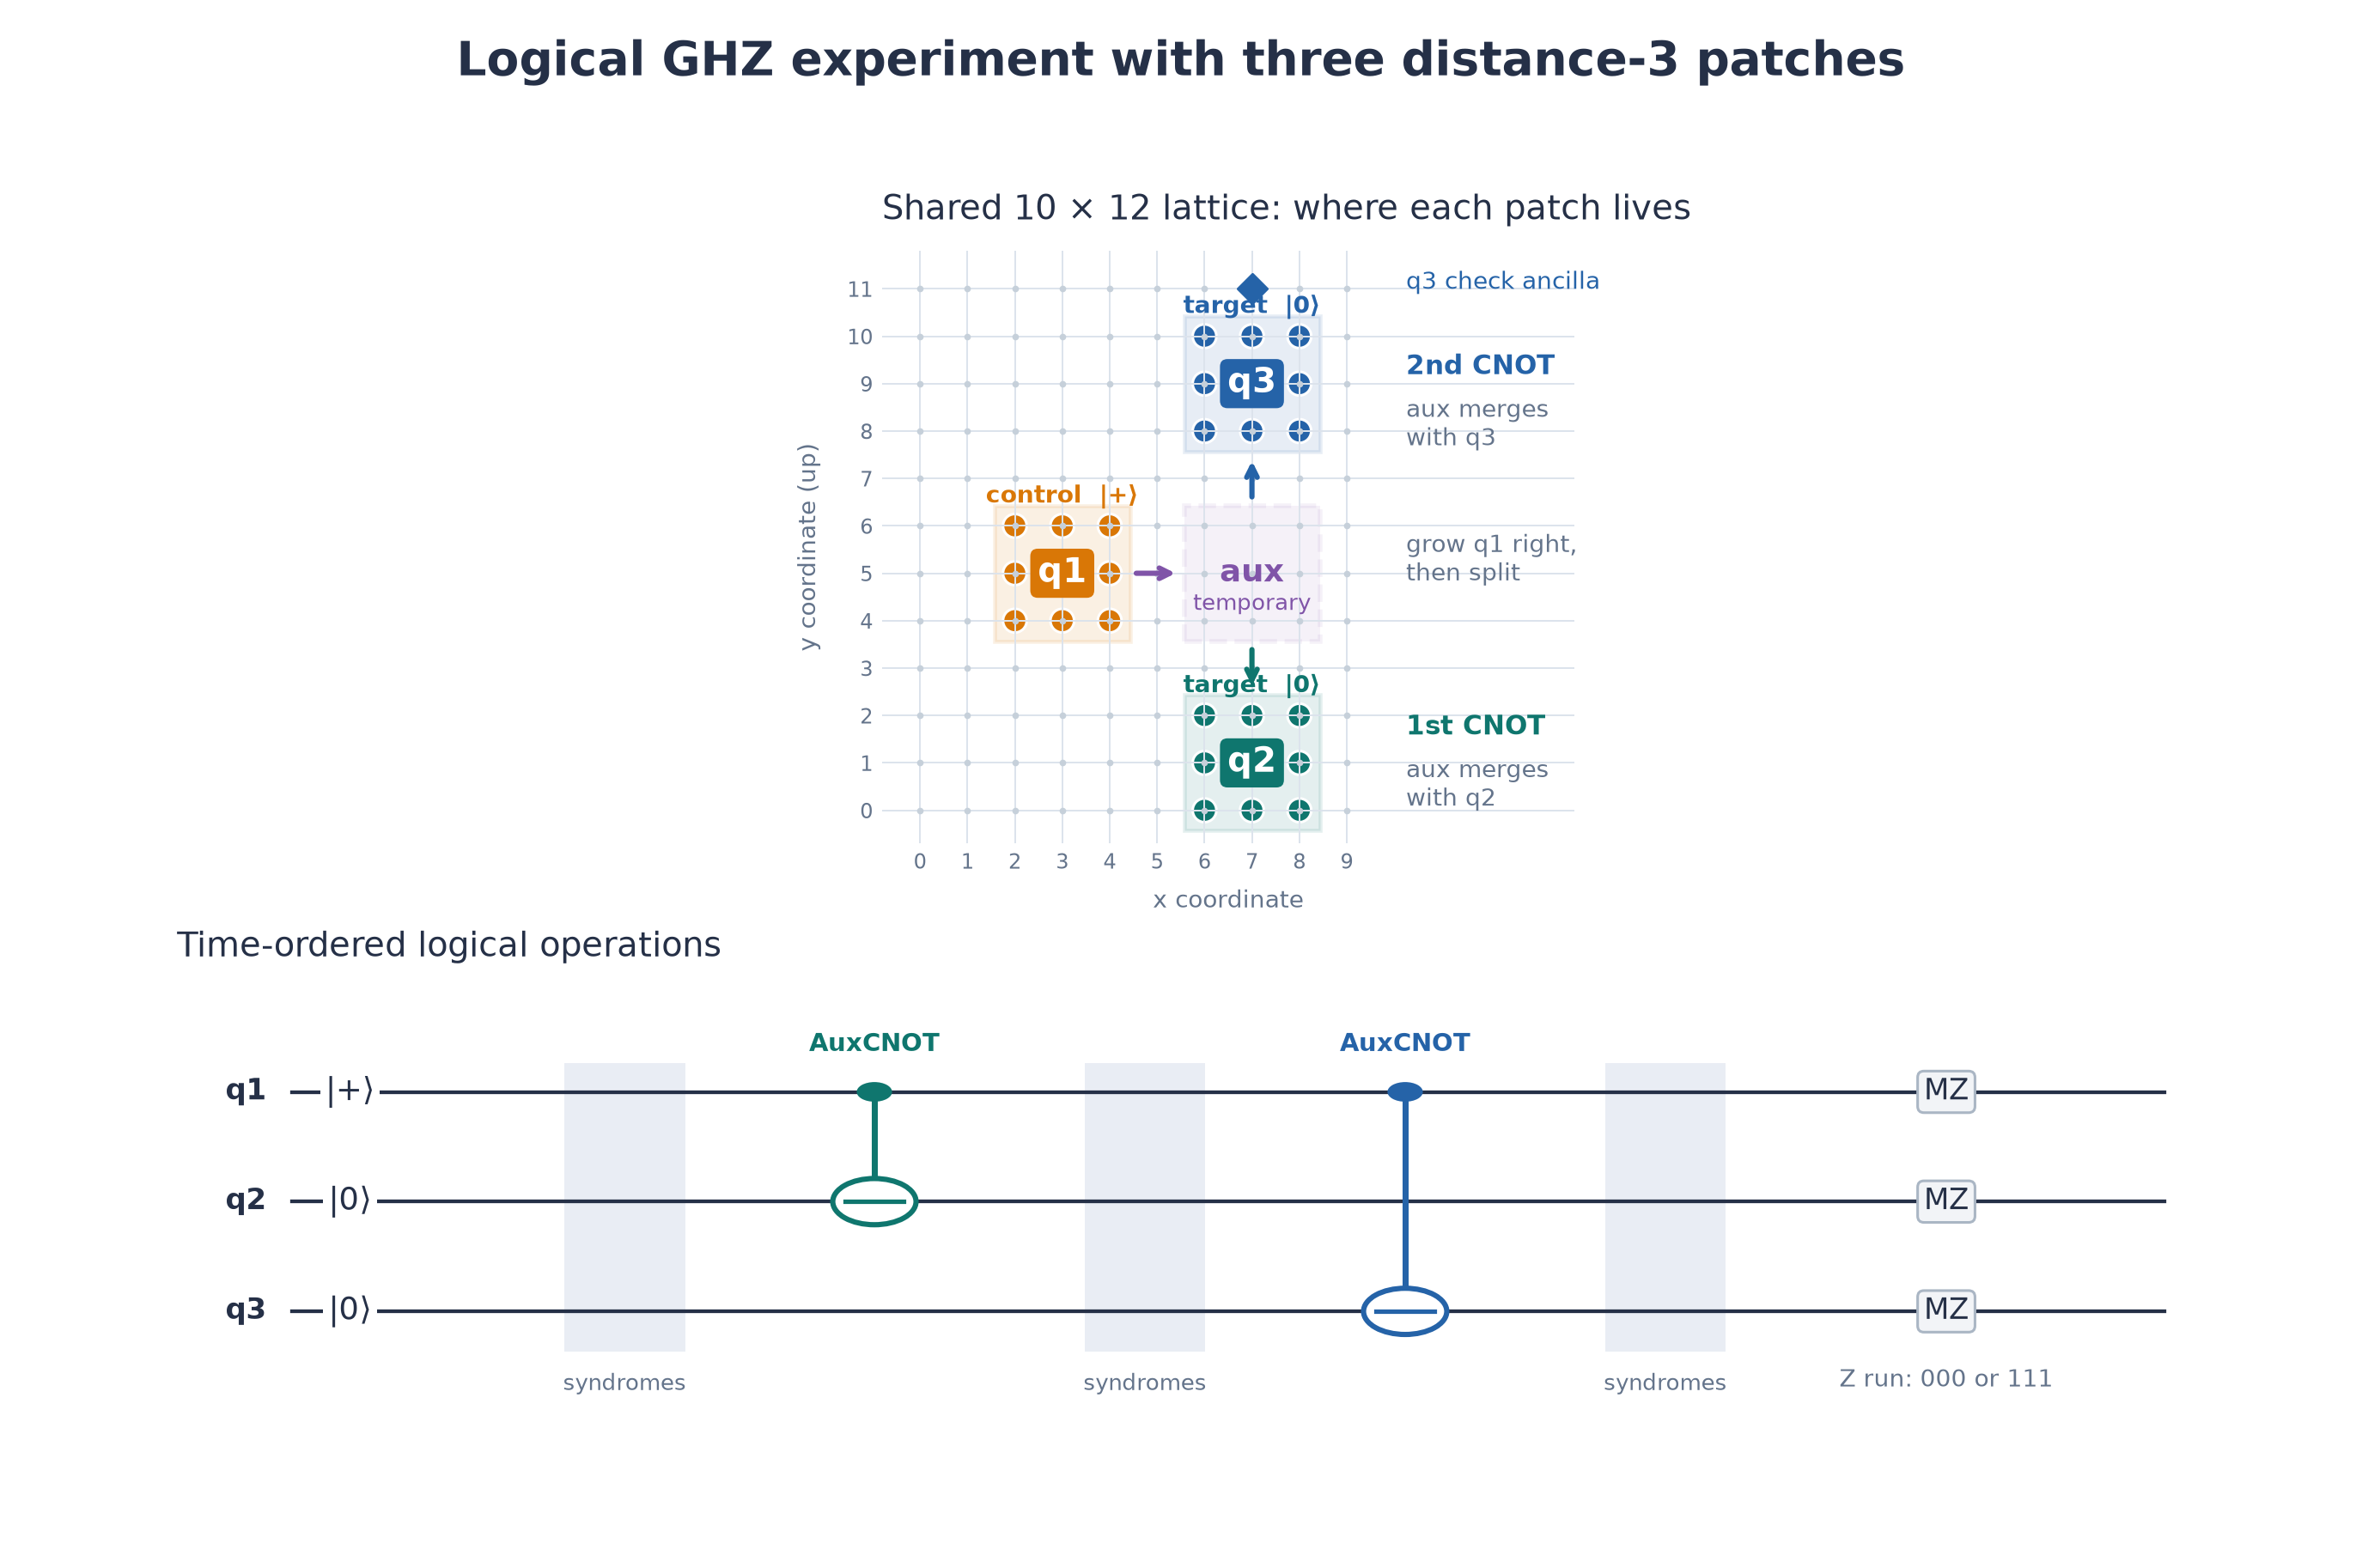


In [5]:
lattice = Lattice.square_2d((10,12))
q1 = RotatedSurfaceCode.create(
    dx=3,
    dz=3,
    position=(2, 4),        
    x_boundary="horizontal",
    weight_2_stab_is_first_row=True,
    lattice=lattice,
    unique_label="q1",
)
q2 = RotatedSurfaceCode.create(
    dx=3,
    dz=3,
    position=(6, 0),
    x_boundary="horizontal",
    weight_2_stab_is_first_row=True,
    lattice=lattice,
    unique_label="q2",
)

q3 = RotatedSurfaceCode.create(
    dx=3,
    dz=3,
    position=(6, 8),
    x_boundary="horizontal",
    weight_2_stab_is_first_row=True,
    lattice=lattice,
    unique_label="q3",
)

blocks = [q1, q2, q3]


### Prepare the logical GHZ circuit

Each inner tuple below is a time frame. Its operations act on the named patches in parallel. `n_cycles=3` means three consecutive rounds of stabilizer measurements at each explicit syndrome step. Each `AuxCNOT` also includes its own surgery and check rounds. The first CNOT entangles `q1` with `q2`. The second extends the entanglement to `q3`.


In [6]:
from loom_rotated_surface_code.operations import AuxCNOT

n_cycles = 3

operations = (
        (
            ResetAllDataQubits("q1", state="+"),
            ResetAllDataQubits("q2", state="0"),
            ResetAllDataQubits("q3", state="0"),
        ),
        (
            MeasureBlockSyndromes("q1", n_cycles=n_cycles), # stabilizes n_cycles times
            MeasureBlockSyndromes("q2", n_cycles=n_cycles),
            MeasureBlockSyndromes("q3", n_cycles=n_cycles),
        ),
        (
            AuxCNOT(("q1", "q2")),
        ),
        (
            MeasureBlockSyndromes("q1", n_cycles=n_cycles),
            MeasureBlockSyndromes("q2", n_cycles=n_cycles),
            MeasureBlockSyndromes("q3", n_cycles=n_cycles),
        ),
        (
            AuxCNOT(("q1", "q3")),
        ),
        (
            MeasureBlockSyndromes("q1", n_cycles=n_cycles),
            MeasureBlockSyndromes("q2", n_cycles=n_cycles),
            MeasureBlockSyndromes("q3", n_cycles=n_cycles),
        ),
        (
            MeasureLogicalZ("q1"),
            MeasureLogicalZ("q2"),
            MeasureLogicalZ("q3"),
        ),
    )

### Convert the GHZ experiment and add gate noise

`interpret_eka` turns our logical operations into a circuit. We convert it to Stim twice: once without noise and once with noise. As in the memory experiment, the noisy version applies independent `DEPOLARIZE1(p_gate)` faults to both participants after each selected `cx` or `cz` gate. Resets, readout, and idle time remain ideal.

In [7]:
eka_result = Eka(lattice, blocks=blocks, operations=operations)
ghz_circ = interpret_eka(eka_result, debug_mode=False)

p_gate = 1e-3
gate_noise = CircuitErrorModel(
    circuit=ghz_circ.final_circuit,
    error_type=ErrorType.DEPOLARIZING1,
    is_time_dependent=False,
    application_mode=ApplicationMode.AFTER_GATE,
    gate_error_probabilities={
        "cx": lambda _: [p_gate],
        "cz": lambda _: [p_gate],
    },
)

converter = EkaToStimConverter()
stim_circuit, _, _ = converter.convert(ghz_circ, with_ticks=True)
noisy_stim_circuit, _, _ = converter.convert(
    ghz_circ,
    error_models=[gate_noise],
    with_ticks=True,
)

### Check the GHZ correlations

We sample the ideal and noisy circuits 1,000 times. Loom records the three final logical Z measurements as Stim observables in the order `q1`, `q2`, `q3`. XOR gives the measured parities \(Z_1Z_2\) and \(Z_2Z_3\). For an ideal GHZ state, both parity bits are 0 on every shot, corresponding to eigenvalue $+1$.

We also count detector clicks. A detector click signals an unexpected change in a stabilizer measurement. The parity failures reported here are raw results because we have not applied a decoder.

In [8]:
import numpy as np

n_samples = 1000
circuits = {
    "noiseless circuit": stim_circuit,
    "noisy circuit": noisy_stim_circuit,
}

for name, circuit in circuits.items():
    detectors, logical_z = circuit.compile_detector_sampler().sample(
        shots=n_samples,
        separate_observables=True,
    )

    z1z2 = logical_z[:, 0] ^ logical_z[:, 1]
    z2z3 = logical_z[:, 1] ^ logical_z[:, 2]

    for label, parity in {"Z1Z2": z1z2, "Z2Z3": z2z3}.items():
        counts = np.bincount(parity.astype(int), minlength=2)
        print(f"{label} counts for {name}: {{'0': {counts[0]}, '1': {counts[1]}}}")

    failed_shots = np.count_nonzero(z1z2 | z2z3)
    shots_with_detector = np.count_nonzero(np.any(detectors, axis=1))

    print(f"Shots with a failed GHZ Z correlation: {failed_shots}/{n_samples}")
    print(f"Shots with at least one detector click: {shots_with_detector}/{n_samples}")
    print(f"Total detector clicks: {np.count_nonzero(detectors)}")
    print()

Z1Z2 counts for noiseless circuit: {'0': 1000, '1': 0}
Z2Z3 counts for noiseless circuit: {'0': 1000, '1': 0}
Shots with a failed GHZ Z correlation: 0/1000
Shots with at least one detector click: 0/1000
Total detector clicks: 0

Z1Z2 counts for noisy circuit: {'0': 793, '1': 207}
Z2Z3 counts for noisy circuit: {'0': 728, '1': 272}
Shots with a failed GHZ Z correlation: 327/1000
Shots with at least one detector click: 964/1000
Total detector clicks: 6835



### Check GHZ coherence in the X basis

The Z-basis test shows that the three readouts agree, but a classical mixture of `000` and `111` would pass it too. We therefore repeat the same ideal preparation and change only the final measurements to logical X. The GHZ state has $X_1X_2X_3=+1$, which appears as an even parity bit, `0`, on every ideal shot. These are separate runs because one terminal measurement cannot read a patch in both bases.


In [9]:
from loom.eka.operations import MeasureLogicalX

x_operations = (
    *operations[:-1],
    (MeasureLogicalX("q1"), MeasureLogicalX("q2"), MeasureLogicalX("q3")),
)
x_eka = Eka(lattice, blocks=blocks, operations=x_operations)
x_interpreted = interpret_eka(x_eka, debug_mode=False)
x_stim_circuit, _, _ = EkaToStimConverter().convert(
    x_interpreted, with_ticks=True
)

_, logical_x = x_stim_circuit.compile_detector_sampler(seed=321).sample(
    shots=n_samples,
    separate_observables=True,
)
x_parity = np.bitwise_xor.reduce(logical_x, axis=1)
x_counts = np.bincount(x_parity.astype(int), minlength=2)
print(f"X1X2X3 parity 0 (+1): {x_counts[0]}/{n_samples}")
print(f"X1X2X3 parity 1 (-1): {x_counts[1]}/{n_samples}")


X1X2X3 parity 0 (+1): 1000/1000
X1X2X3 parity 1 (-1): 0/1000


## Summary

We built a distance-four rotated surface-code patch and tested a logical-Z memory. Its ideal readout stayed at the prepared value. Under independent `DEPOLARIZE1` faults after selected ancilla–data `cx` and `cz` gates, detector clicks and raw readout failures appeared. The small-$p$ failure rate is approximately linear because an uncorrected single fault can flip this readout.

We then placed three distance-three patches on a shared lattice. Two lattice-surgery `AuxCNOT` operations prepared a logical GHZ state. In the ideal simulations, $Z_1Z_2=Z_2Z_3=+1$ showed Z-basis correlation, while $X_1X_2X_3=+1$ checked coherence. Gate noise caused some Z correlations to fail.

These are **raw** results. We recorded detector events but did not use a decoder to correct the logical readouts. The noise model leaves resets, measurements, and idle time ideal.
